In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RepeatedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance

In [68]:
# =========================
# CONFIG
# =========================
TARGET = "delay_days"
DELAY_THRESHOLD = 5            # for derived classification check
USE_LOG_TARGET = True       # log1p transform to tame skew   -> log1p = log(1+x)
USE_SAMPLE_WEIGHTS = True      # emphasize larger delays during training
RANDOM_STATE = 42

In [69]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [70]:
# =========================
# SPLIT + TARGET
# =========================
df = df.copy()
# (optional) clip impossible outliers while keeping signal
df[TARGET] = np.clip(df[TARGET], 0, 30)         # clipping the maximum delay to 30 days

y = df[TARGET].astype(float)
X = df.drop(columns=[TARGET])

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [71]:
# target transform (log1p helps a lot with right-skew)
if USE_LOG_TARGET:
    y_train = np.log1p(y_train_raw)
    y_test  = np.log1p(y_test_raw)
    inv = np.expm1
else:
    y_train = y_train_raw.copy()
    y_test  = y_test_raw.copy()
    inv = lambda z: z

In [72]:
# regression “balancing”: sample weights that up-weight long delays
if USE_SAMPLE_WEIGHTS:
    rng = (y_train_raw.max() - y_train_raw.min()) or 1.0
    w_train = 1.0 + (y_train_raw - y_train_raw.min()) / rng           # ~[1,2]
    # for stronger emphasis use: np.exp((y_train_raw - y_train_raw.min()) / rng)
else:
    w_train = None

In [73]:
# =========================
# PREPROCESSING
# =========================
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

In [74]:
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

In [75]:
# preprocess = ColumnTransformer(
#     transformers=[
#         ("num", "passthrough", num_cols),
#         ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
#     ],
#     remainder="drop"
# )

In [76]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            cat_cols,
        ),
    ],
    remainder="drop",
)

In [77]:
# =========================
# MODEL + GRID
# =========================
gbr = GradientBoostingRegressor(
    random_state=RANDOM_STATE,
    loss="absolute_error"  # try 'huber' for outlier-robust training
)

pipe = Pipeline([("prep", preprocess), ("model", gbr)])

param_grid = {
    "model__n_estimators": [300, 500],
    "model__learning_rate": [0.01, 0.05],
    "model__max_depth": [3, 5],
    "model__subsample": [1.0, 0.8],
    "model__min_samples_leaf": [1, 2]
}

cv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=RANDOM_STATE)

gs = GridSearchCV(
    pipe,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [78]:
# fit (pass sample_weight if enabled)
fit_kwargs = {"model__sample_weight": w_train} if w_train is not None else {}
gs.fit(X_train, y_train, **fit_kwargs)

best_gbr = gs.best_estimator_
print("Best params:", gs.best_params_)

# =========================
# EVALUATE (on original scale)
# =========================
y_pred_test = inv(best_gbr.predict(X_test))
y_true_test = y_test_raw

mae  = mean_absolute_error(y_true_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
r2   = r2_score(y_true_test, y_pred_test)
print(f"MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits


Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_837777_55733f6a4a1f4af9856fb7f618887113_716652c9346c4dd8b734d76d0e2ee928 for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_837777_88f3977dfefc4ef790e0b69c795e785e_bbcaa53714884d27a2cfe369e97cfe03 for automatic cleanup: unknown resource type folder


Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /dev/shm/joblib_memmapping_folder_837777_88f3977dfefc4ef790e0b69c795e785e_bbcaa53714884d27a2cfe369e97cfe03 for automatic cleanup: unknown resource type folder


Best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__n_estimators': 500, 'model__subsample': 0.8}
MAE=1.211  RMSE=1.614  R²=0.664


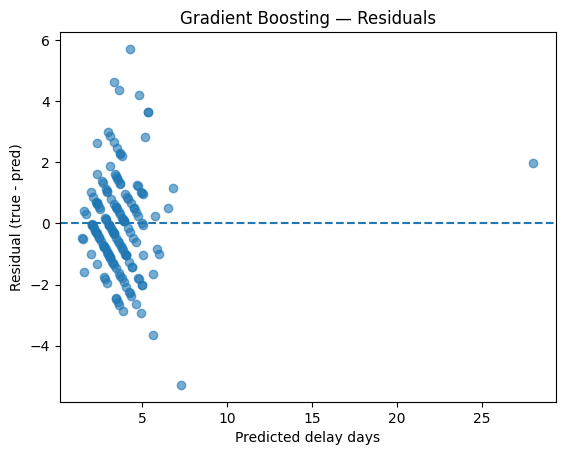

In [79]:
# residuals
resid = y_true_test - y_pred_test
plt.figure()
plt.scatter(y_pred_test, resid, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted delay days")
plt.ylabel("Residual (true - pred)")
plt.title("Gradient Boosting — Residuals")
plt.show()

In [80]:
# =========================
# PERMUTATION IMPORTANCE
# =========================
# build post-encoding feature names
# ohe = best_gbr.named_steps["prep"].named_transformers_.get("cat", None)
# ohe_cols = ohe.get_feature_names_out(cat_cols).tolist() if ohe is not None else []
# feat_names = num_cols + ohe_cols

# use log target for importance if you trained in log space
target_for_importance = y_test if USE_LOG_TARGET else y_test_raw

# perm = permutation_importance(best_gbr, X_test, target_for_importance, n_repeats=10,
#                               random_state=RANDOM_STATE, n_jobs=-1)
# imp = pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=False)
# print("\nTop 20 permutation importances:")
# print(imp.head(20))

# plt.figure(figsize=(8, 10))
# imp.head(25).iloc[::-1].plot(kind="barh")
# plt.title("Permutation Importance — Gradient Boosting")
# plt.tight_layout()
# plt.show()


Derived classification (threshold > 5 days):
[[129   9]
 [ 14   9]]
              precision    recall  f1-score   support

           0      0.902     0.935     0.918       138
           1      0.500     0.391     0.439        23

    accuracy                          0.857       161
   macro avg      0.701     0.663     0.679       161
weighted avg      0.845     0.857     0.850       161



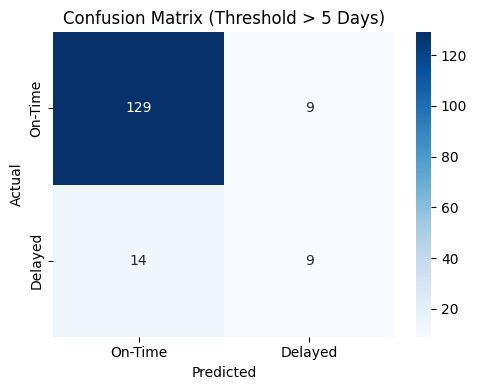

In [81]:
# =========================
# OPTIONAL: derive classification (>5 days)
# =========================
pred_is_delayed = (y_pred_test > DELAY_THRESHOLD).astype(int)
actual_is_delayed = (y_true_test > DELAY_THRESHOLD).astype(int)

print("\nDerived classification (threshold > 5 days):")
print(confusion_matrix(actual_is_delayed, pred_is_delayed))
print(classification_report(actual_is_delayed, pred_is_delayed, digits=3))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# --- Confusion Matrix Plot ---
cm = confusion_matrix(actual_is_delayed, pred_is_delayed)
labels = ['On-Time', 'Delayed']

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (Threshold > 5 Days)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Inferencing

In [82]:
import pandas as pd
import numpy as np

# Single new observation
new_data = pd.DataFrame([{
    "shipping_duration_days": 21,
    "lead_time_days": 60,
    "is_early_delivery": 0,
    "scac": "SMLU",
    "tariff_amount": 18847.5,
    "ocean_freight": 0.0,
    "delivery_terms": "CY",
    "po_shipment_terms": "DDP",
    "tariff_type": "Price With",
    "total_bcy": 167650.0,
    "quantity_in": 35000.0,
    "item_sku": "855",
    "item_brand": "GREAT",
    "item_manufacturer": "s",
    "item_product_category": "Goods",
    "item_size": "26/30",
    "vendor_name": "IPSP, INC.",
    "vendor_avg_delay_days": 5.8,
    "vendor_shipments": 5,
    "vendor_on_time_rate": 0.0,
    "vendor_p50_delay_days": 5,
    "vendor_p90_delay_days": 11,
    "shipped_date_weekday": 4,
    "shipped_date_month": 9,
    "shipped_date_day": 26,
    "distance_nm": 2100
}])

# Keep columns in the same order as training
new_data = new_data[X.columns]

new_data[num_cols] = new_data[num_cols].astype(float)


In [83]:
# Use trained pipeline (best_gbr from your GridSearchCV)
predicted_delay_log = best_gbr.predict(new_data)

# If you trained with log1p transform
predicted_delay_days = np.expm1(predicted_delay_log)

print(f"Predicted Delay Days: {predicted_delay_days[0]:.2f}")


Predicted Delay Days: 5.97


In [84]:
is_predicted_delayed = int(predicted_delay_days[0] > 5)
print("Predicted Class:", "DELAYED" if is_predicted_delayed else "ON-TIME")

Predicted Class: DELAYED


## Explaning the result of Gradient Boosting

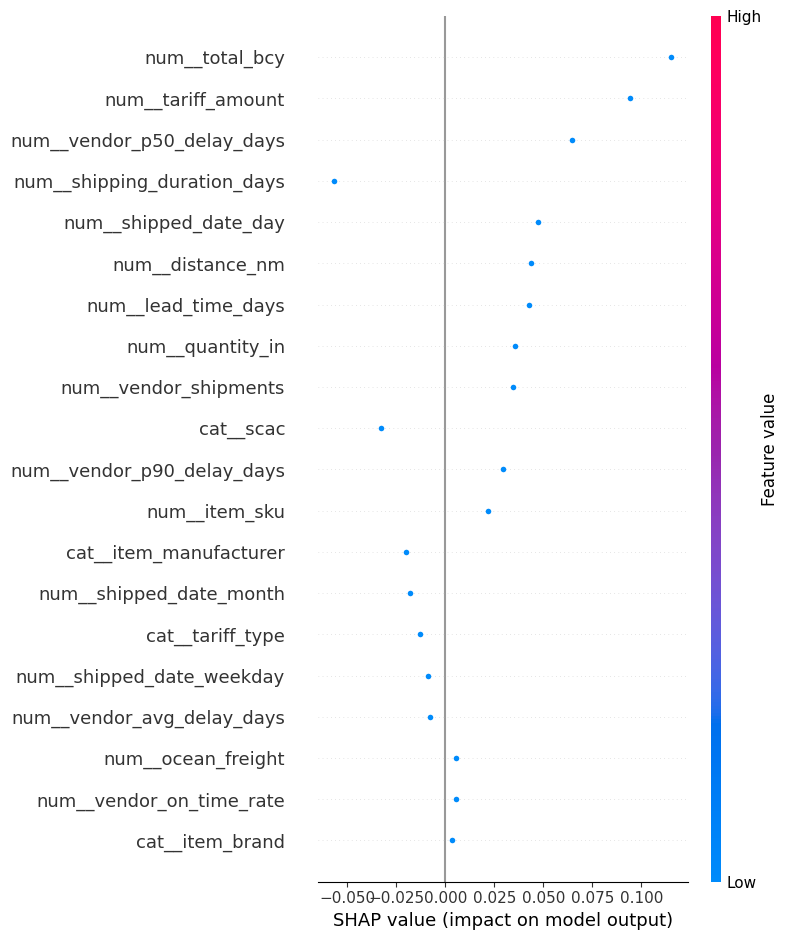

In [85]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(best_gbr.named_steps['model'], 
                           feature_names=best_gbr.named_steps['prep'].get_feature_names_out())

# Compute SHAP values on your test data
X_test_transformed = best_gbr.named_steps['prep'].transform(new_data)
shap_values = explainer(X_test_transformed)

# Global summary plot
shap.summary_plot(shap_values, features=X_test_transformed, feature_names=best_gbr.named_steps['prep'].get_feature_names_out())


In [86]:
new_data

,shipping_duration_days,lead_time_days,is_early_delivery,scac,tariff_amount,ocean_freight,delivery_terms,po_shipment_terms,tariff_type,total_bcy,...,vendor_name,vendor_avg_delay_days,vendor_shipments,vendor_on_time_rate,vendor_p50_delay_days,vendor_p90_delay_days,shipped_date_weekday,shipped_date_month,shipped_date_day,distance_nm
0,21.0,60.0,0.0,SMLU,18847.5,0.0,CY,DDP,Price With,167650.0,...,"IPSP, INC.",5.8,5.0,0.0,5.0,11.0,4.0,9.0,26.0,2100.0


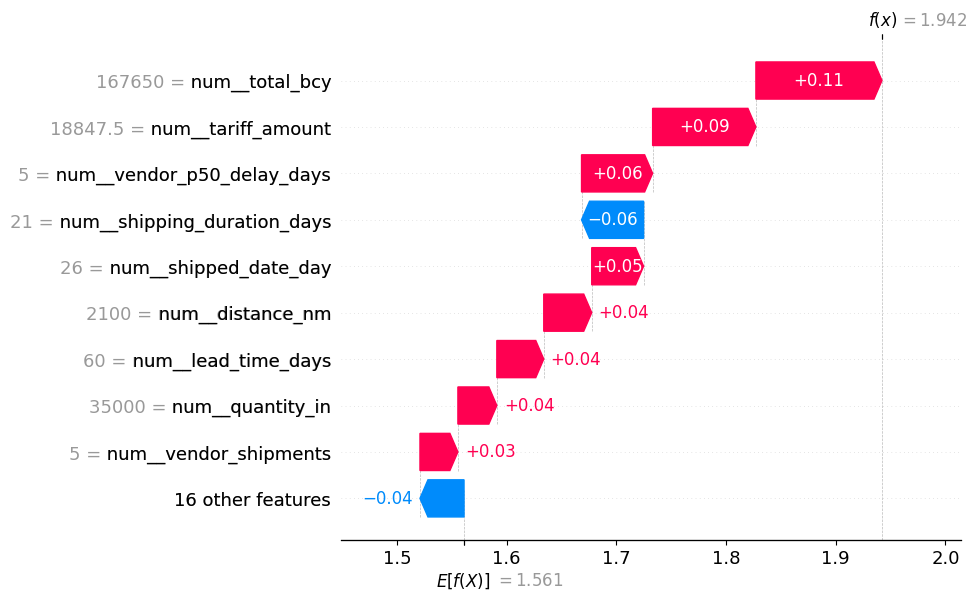

In [87]:
# 1️⃣ Transform the new data
new_data_transformed = best_gbr.named_steps['prep'].transform(new_data)

# 2️⃣ Get SHAP values
shap_values_single = explainer(new_data_transformed)

# 3️⃣ Visualize explanation for that one prediction
shap.plots.waterfall(shap_values_single[0])


In [88]:
(shap_values_single[0])

.values =
array([-5.65664682e-02,  4.27721176e-02,  0.00000000e+00,  9.41543902e-02,
        5.25685518e-03,  1.14925129e-01,  3.54942121e-02,  2.19740675e-02,
       -7.73933668e-03,  3.45807032e-02,  5.23240803e-03,  6.48030709e-02,
        2.93743352e-02, -9.09778432e-03, -1.79187335e-02,  4.72783061e-02,
        4.37373197e-02, -3.26288456e-02, -7.94333317e-04, -2.64527086e-03,
       -1.28250886e-02,  3.13105258e-03, -2.00129775e-02,  8.37228008e-05,
       -1.55744016e-03])

.base_values =
np.float64(1.5611386576772182)

.data =
array([ 2.10000e+01,  6.00000e+01,  0.00000e+00,  1.88475e+04,
        0.00000e+00,  1.67650e+05,  3.50000e+04,  8.55000e+02,
        5.80000e+00,  5.00000e+00,  0.00000e+00,  5.00000e+00,
        1.10000e+01,  4.00000e+00,  9.00000e+00,  2.60000e+01,
        2.10000e+03,  9.00000e+00,  0.00000e+00,  2.00000e+00,
       -1.00000e+00, -1.00000e+00, -1.00000e+00,  5.00000e+00,
        3.00000e+00])

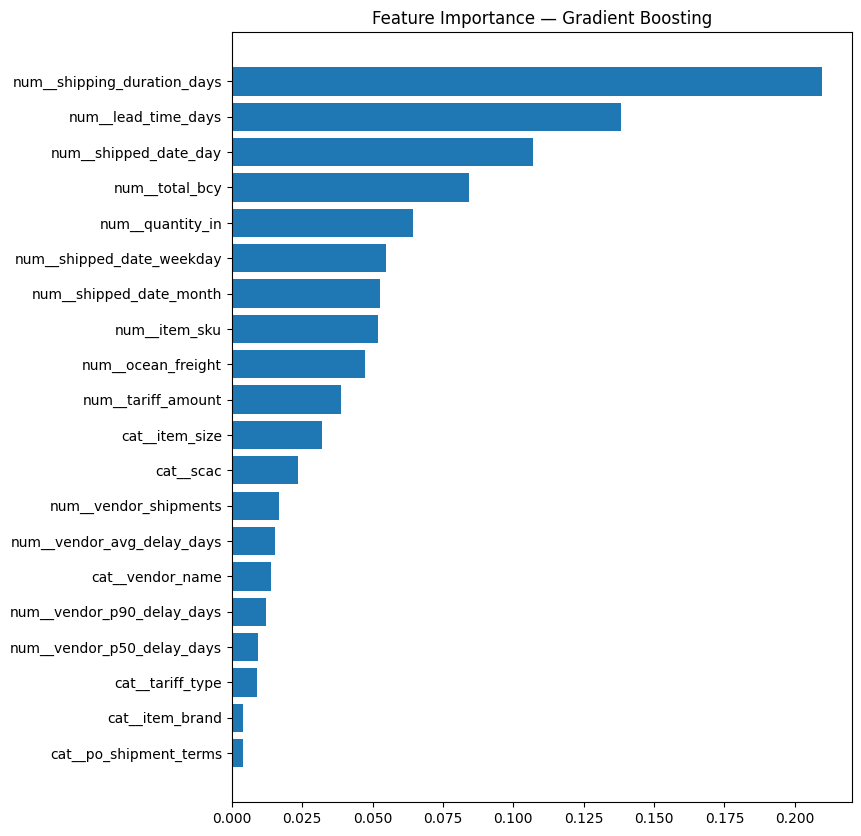

In [89]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = best_gbr.named_steps['prep'].get_feature_names_out()
importances = best_gbr.named_steps['model'].feature_importances_

# Sort and plot
indices = np.argsort(importances)[-20:]
plt.figure(figsize=(8, 10))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Feature Importance — Gradient Boosting")
plt.show()

## Explaning using LLM

In [90]:
from openai import OpenAI
from dotenv import load_dotenv
import os
load_dotenv()

def generate_response(user_query):

    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    system_prompt = """You are an expert data scientist specializing in machine learning model explanations. 
    Your task is to help explain the predictions of a model trained to predict shipment delay days.
    The feature values for a shipment, provide a clear, concise explanation of features that contributes to the predicted delay days.
    Focus on the most impactful features and how they may have influenced the delay.
    Try to keep the explanation based on the data provided.
    Try to find the root cause behind the delay.
    Avoid using technical jargon; explain in simple terms.
    Try to explain the predictions in 2 lines at maximum and at maximum 75 words.
    Do not use the feature names directly in the explanation.

    Here is the idea behind the features provided:
    - shipping_duration_days: Expected duration of the shipment in days.
    - lead_time_days: Number of days between order placement and shipment.
    - is_early_delivery: Indicator if the delivery was early (1) or not (0).
    - coo: Country of origin of the shipment.
    - scac: Standard Carrier Alpha Code representing the shipping carrier.
    - tariff_amount: The tariff cost associated with the shipment.
    - ocean_freight: Cost of ocean freight for the shipment.
    - delivery_terms: Terms of delivery (e.g., CY, DDP).
    - po_shipment_terms: Purchase order shipment terms.
    - tariff_type: Type of tariff applied to the shipment.
    - total_bcy: Total cost in base currency.
    - quantity_in: Quantity of items in the shipment.
    - item_sku: Stock Keeping Unit identifier for the item.
    - item_brand: Brand of the item being shipped.
    - item_manufacturer: Manufacturer of the item.
    - item_product_category: Category of the product being shipped.
    - item_size: Size specification of the item.
    - vendor_name: Name of the vendor supplying the item.
    - vendor_avg_delay_days: Average delay days for shipments from this vendor.
    - vendor_shipments: Total number of shipments made by this vendor.
    - vendor_on_time_rate: Percentage of on-time deliveries by this vendor.
    - vendor_p50_delay_days: 50th percentile delay days for this vendor.
    - vendor_p90_delay_days: 90th percentile delay days for this vendor.
    - shipped_date_weekday: Day of the week the shipment was sent (0=Monday, 6=Sunday).
    - shipped_date_month: Month the shipment was sent (1-12).
    - shipped_date_day: Day of the month the shipment was sent (1-31).
    
    Output can be something like:
    "For the given shipment, it seems that predicted arrival date seems to be 5 days beyond committed ETA.
    This analysis has taken place considering the particular supplier has average of 5 days delay on previous shipment overall...."
    """

    response = client.chat.completions.create(
        model="gpt-4",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_query}
        ],
        max_tokens=100
    )

    return response.choices[0].message.content

In [91]:
import pandas as pd

# Create the DataFrame
df_new = pd.read_csv('./results/raw_shipment_classification_inference_dataset.csv')

df_new.head()

,delay_days,shipping_duration_days,lead_time_days,is_early_delivery,scac,tariff_amount,ocean_freight,delivery_terms,po_shipment_terms,tariff_type,...,vendor_name,vendor_avg_delay_days,vendor_shipments,vendor_on_time_rate,vendor_p50_delay_days,vendor_p90_delay_days,shipped_date_weekday,shipped_date_month,shipped_date_day,distance_nm
0,5,54.0,98,0.0,CMDU,37408.0,5800.00,CY,DDP,Price With Tariff,...,Aquatica Frozen Foods Global Pvt Ltd,4.16,101,0.05,3,6,3,8,7,11000
1,5,54.0,80,0.0,CMDU,66454.5,5500.00,CY,DDP,Price With Tariff,...,Sunrise Seafoods India Pvt. Ltd,2.60,5,0.20,3,5,3,8,7,11000
2,1,50.0,98,0.0,CMDU,39693.0,6394.32,CY,CIF,Price Without Tariff,...,Suryamitra Exim LTD,3.05,75,0.24,3,6,3,8,7,11000
3,5,54.0,98,0.0,CMDU,35933.0,7200.62,CY,CIF,Price Without Tariff,...,Suryamitra Exim LTD,3.05,75,0.24,3,6,3,8,7,11000
4,5,54.0,90,0.0,CMDU,35979.5,6300.80,CY,CIF,Price Without Tariff,...,Suryamitra Exim LTD,3.05,75,0.24,3,6,3,8,7,11000


In [92]:
df_new.columns

Index(['delay_days', 'shipping_duration_days', 'lead_time_days',
       'is_early_delivery', 'scac', 'tariff_amount', 'ocean_freight',
       'delivery_terms', 'po_shipment_terms', 'tariff_type', 'total_bcy',
       'quantity_in', 'item_sku', 'item_brand', 'item_manufacturer',
       'item_size', 'vendor_name', 'vendor_avg_delay_days', 'vendor_shipments',
       'vendor_on_time_rate', 'vendor_p50_delay_days', 'vendor_p90_delay_days',
       'shipped_date_weekday', 'shipped_date_month', 'shipped_date_day',
       'distance_nm'],
      dtype='object')

In [93]:
# Drop target if you're predicting (we already have delay_days here, but we can ignore it)
X_new = df_new.drop(columns=["delay_days"])

# Predict delay days
pred_log = best_gbr.predict(X_new)
pred_days = np.expm1(pred_log)
df_new["predicted_delay_days"] = pred_days.round(2)

# Derive classification (delayed vs not delayed)
df_new["predicted_is_delayed"] = (df_new["predicted_delay_days"] > 5).astype(int)

In [94]:
delay_predicted_data = df_new[df_new["predicted_is_delayed"] == 1]

In [ ]:
delay_predicted_data.iloc[-1, :]

delay_days                                          31
shipping_duration_days                            77.0
lead_time_days                                      37
is_early_delivery                                  0.0
scac                                              CMDU
tariff_amount                                   8828.7
ocean_freight                                  5001.19
delivery_terms                                      CY
po_shipment_terms                                  CNF
tariff_type                       Price Without Tariff
total_bcy                                      93288.0
quantity_in                                    31200.0
item_sku                                           873
item_brand                                 GREAT VALUE
item_manufacturer                             VANNAMEI
item_size                                        60/80
vendor_name               Sandhya Aqua Exports Pvt Ltd
vendor_avg_delay_days                             3.74
vendor_shi

Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-837777-pou_01bb for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-837777-d2rxgcnn for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/resource_tracker.py", line 295, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-837777-9zjb38l5 for automatic cleanup

In [96]:
delay_data = delay_predicted_data[X.columns].iloc[[0], :]

In [97]:
type(delay_data)

pandas.core.frame.DataFrame

In [98]:
for i in range(0,5):
    delay_data = delay_predicted_data[X.columns].iloc[[i], :]
    new_data_transformed = best_gbr.named_steps['prep'].transform(delay_data)
    shap_values_single = explainer(new_data_transformed)
    user_query = f"""Given the following feature values for a shipment:
    {delay_data.to_dict(orient='records')[0]}
    The model predicted a delay of {predicted_delay_days[0]:.2f} days.
    Please explain how the key features influenced this prediction.
    Shap values for the features are:
    {shap_values_single.values[0]}
    """
    response = generate_response(user_query)
    print(response)
    print("-----")

The forecasted delay of nearly 6 days is primarily influenced by the time it usually takes for the shipping company to deliver, as well as past performance of this vendor in terms of delays. Specifically, this vendor typically has an average delay of 4 days, which has likely influenced the expected delay. The length and complexity of the total shipping time can also play a part.
-----
The shipment delay prediction primarily considers the vendor's historical performance and the shipping duration. With this vendor often having average 3.74 days delay and factoring in the shipping duration of 79 days, the model forecasted a delay of approximately 5.97 days. Shipment-related charges and the shipping carrier also marginally affected the prediction.
-----
The predicted shipment delay of approximately 6 days is primarily influenced by the supplier's history of late deliveries, which on average is about 4 days late. The time it takes for the shipment to reach its destination also contributes t

In [99]:
print(predicted_delay_days)

[5.97372886]
